In [2]:
using Pkg
Pkg.instantiate()
using QAlgebra
using BenchmarkTools

In [4]:
subspace_def = SubSpaceDefinitions( h=QubitPM("beta"), 
                                    i=Ensemble(3, 3, QubitPauli("sigma"), as_continuum=true), 
                                    b=Ladder(max_magnitude=4))
op_def = OperatorDefinitions("A(i,t)", "B(U,H,i)")
var_def = ParameterDefinitions( "alpha",# => 2.0, 
                                "beta(t)" => t->t^2, 
                                "delta_i" => QNormal(0,1,2,15), # from 0 to 1 with 10 samples on grid along the gamma dimension
                                "eta_i" => QNormal(0,1,2,15),
                                "gamma_{i,j}(t,delta_i,delta_j)" => (t,gi,gj)->t*(gi-gj)) 
qspace = QSpace(subspace_def, op_def, var_def, max_t_ind=2)

QSpace: [α,β(t),δᵢ,ηᵢ,γᵢˏᵢ(t),t]
   - Subspace: h              → PM Qubit (Fermion):  βᵖₚ,βᵐₚ,βᶻₚ
   - Ensemble: i,j,k, ∑ l,m,n → Pauli Qubit (Fermion):  σˣₚ,σʸₚ,σᶻₚ
   - Subspace: b              → Ladder (Boson):  p
   - Op: A
   - Op: B(H,U)


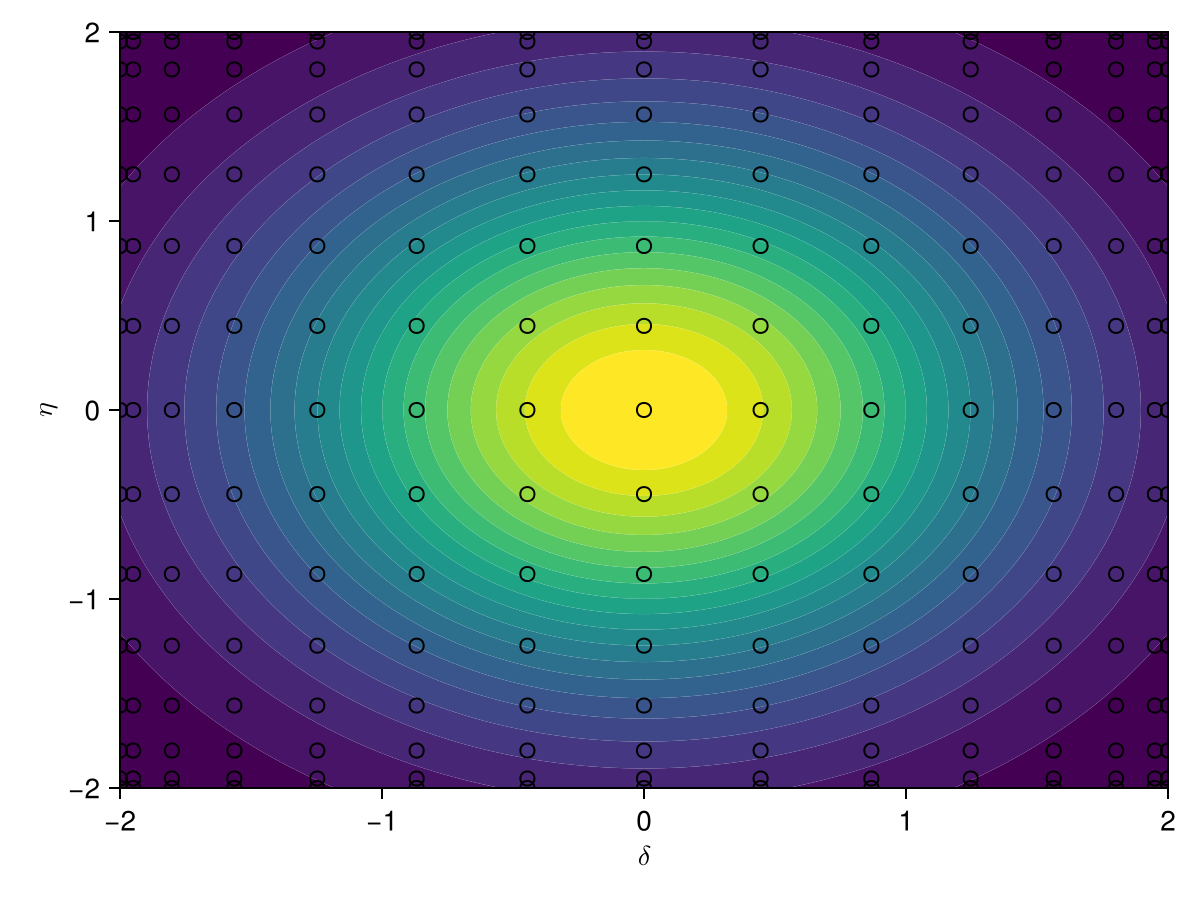

CairoMakie.Screen{IMAGE}


In [5]:
using CairoMakie            # ensures the extension loads
using QAlgebra.Plotting     # opt-in to the plotting API

fig = plot_ensemble_samples(qspace, :i; add_joint_probability=true, color=:transparent, strokewidth=1.0,
    joint_mode=:contourf, joint_kwargs=(; colormap=:viridis, levels=20, transparency=0.35))
display(fig)